# Model Evaluation for XGBoost Classifier

This notebook demonstrates how to evaluate the performance of a trained XGBoost classifier model using various metrics and visualizations. We will use the validation set to assess model accuracy, analyze feature importance, and visualize classification performance using confusion matrix and ROC curve.

## **Loading and Preparing the Model**

Before we proceed with the evaluation, we will load the trained model and the validation data.


In [2]:
import joblib
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_score, recall_score, precision_recall_curve


In [3]:
# Load trained model
model_file = '../models/best_xgboost_model.pkl'
model = joblib.load(model_file)

In [4]:
# Load validation data
valid_file = '../data/bbb_valid_features.csv'
valid_df = pd.read_csv(valid_file)

In [5]:
# Define feature and target columns
target_col = 'Y'
non_feature_cols = ['Drug_ID', 'Drug', 'key', 'input', 'Y']
X_valid = valid_df.drop(columns=non_feature_cols)
y_valid = valid_df[target_col]

In [6]:
# Predicting the validation set
y_pred = model.predict(X_valid)

# Accuracy
accuracy = accuracy_score(y_valid, y_pred)
print(f"Validation Accuracy: {accuracy:.4f}")

# Precision
precision = precision_score(y_valid, y_pred)
print(f"Validation Precision: {precision:.4f}")


Validation Accuracy: 0.8719
Validation Precision: 0.8983


## Accuracy, Precision, Recall, and F1-Score

First, we'll look at the key metrics like **accuracy**, **precision**, **recall**, and **F1-score** on the validation set to understand how well the model is performing.

In [8]:
# Display classification report
report = classification_report(y_valid, y_pred)
print(f"Classification Report:\n{report}")

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.50      0.58        36
           1       0.90      0.95      0.92       167

    accuracy                           0.87       203
   macro avg       0.80      0.73      0.75       203
weighted avg       0.86      0.87      0.86       203



### Explanation:
- **Accuracy**: The proportion of correct predictions (both positive and negative) out of all predictions.
- **Precision**: Out of all the positive predictions, how many were correct.
- **Recall**: Out of all actual positives, how many were identified correctly by the model.
- **F1-score**: The harmonic mean of precision and recall, providing a balance between them.

This gives us a summary of how well the model is performing across all evaluation metrics. A high precision and recall indicate that the model is good at identifying drugs that can cross the BBB.

## Confusion Matrix

The confusion matrix provides a detailed breakdown of the true positives, true negatives, false positives, and false negatives, allowing us to see where the model is making mistakes.

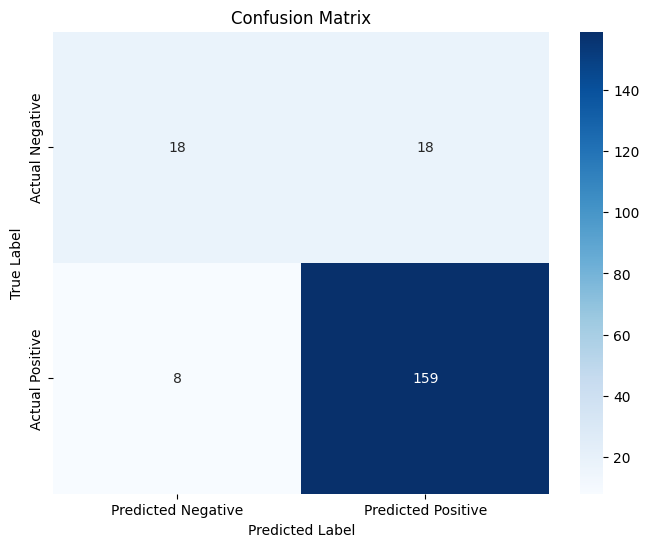

In [11]:
# Compute confusion matrix
conf_matrix = confusion_matrix(y_valid, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Explanation:
- The confusion matrix visually breaks down the model’s predictions:
  - **True Positives (TP)**: Correctly predicted permeable drugs.
  - **True Negatives (TN)**: Correctly predicted non-permeable drugs.
  - **False Positives (FP)**: Predicted permeable when the drug is actually non-permeable.
  - **False Negatives (FN)**: Predicted non-permeable when the drug is actually permeable.

In drug discovery, minimizing false negatives is critical since drugs predicted to not cross the BBB may have critical therapeutic effects that are overlooked.

## ROC Curve (Receiver Operating Characteristic)

The ROC curve plots the True Positive Rate (TPR) against the False Positive Rate (FPR) at various thresholds. The **AUC (Area Under the Curve)** value tells us how well the model distinguishes between classes.

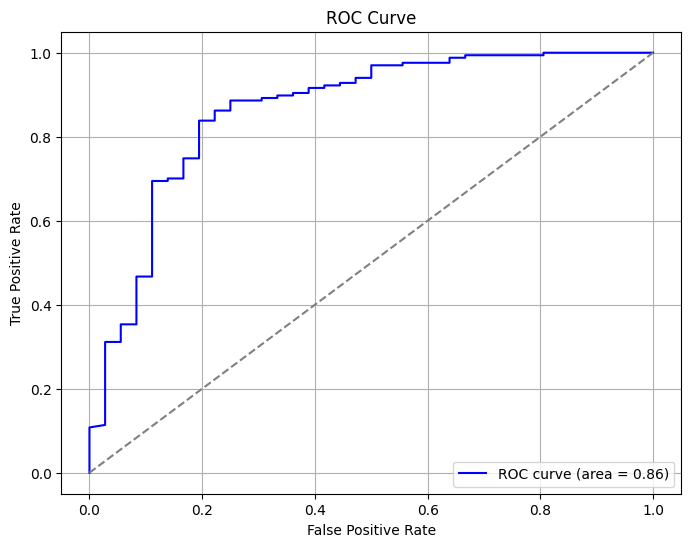

In [16]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get ROC curve values
fpr, tpr, thresholds_roc = roc_curve(y_valid, model.predict_proba(X_valid)[:, 1])

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label='ROC curve (area = %0.2f)' % roc_auc_score(y_valid, model.predict_proba(X_valid)[:, 1]))
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Explanation:
- **AUC-ROC**: The AUC score indicates the model’s ability to distinguish between classes. A higher AUC indicates a better performing model.
- A good model for drug discovery should have an AUC closer to 1, indicating it can effectively differentiate between permeable and non-permeable drugs.

## Precision-Recall Curve

In cases of class imbalance (as in drug discovery, where non-permeable drugs may be much more common), the Precision-Recall curve is more informative than the ROC curve. It focuses on the model's ability to predict the positive class correctly.

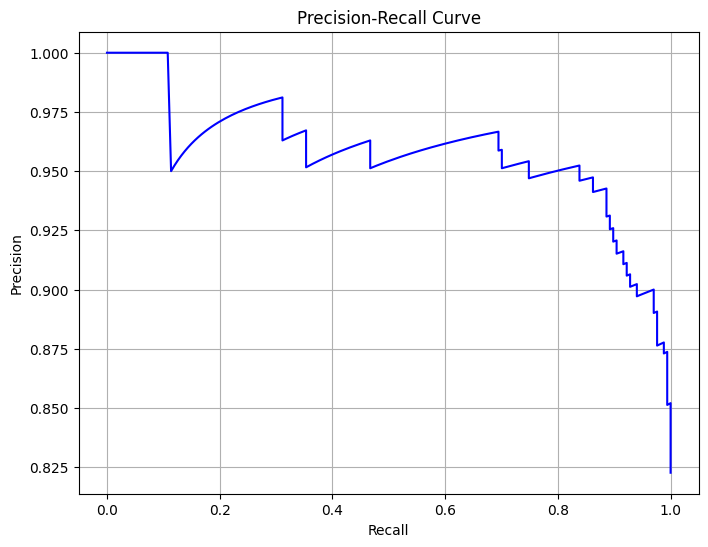

In [18]:
from sklearn.metrics import precision_recall_curve

# Get precision-recall curve values
precision_vals, recall_vals, thresholds = precision_recall_curve(y_valid, model.predict_proba(X_valid)[:, 1])

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals, color='blue')
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.show()

### Explanation:
- The **Precision-Recall curve** helps evaluate how well the model is predicting the positive class (i.e., permeable drugs).
- **Precision** indicates the proportion of true positives out of all positive predictions.
- **Recall** indicates the proportion of true positives out of all actual positives.

A high precision and recall value would mean the model is good at predicting drugs that can cross the BBB without overwhelming false positives.

## Feature Importance

Understanding which features are most influential in making predictions can be critical in drug discovery. Here, we plot the feature importance from the model to see which features the model relies on the most.

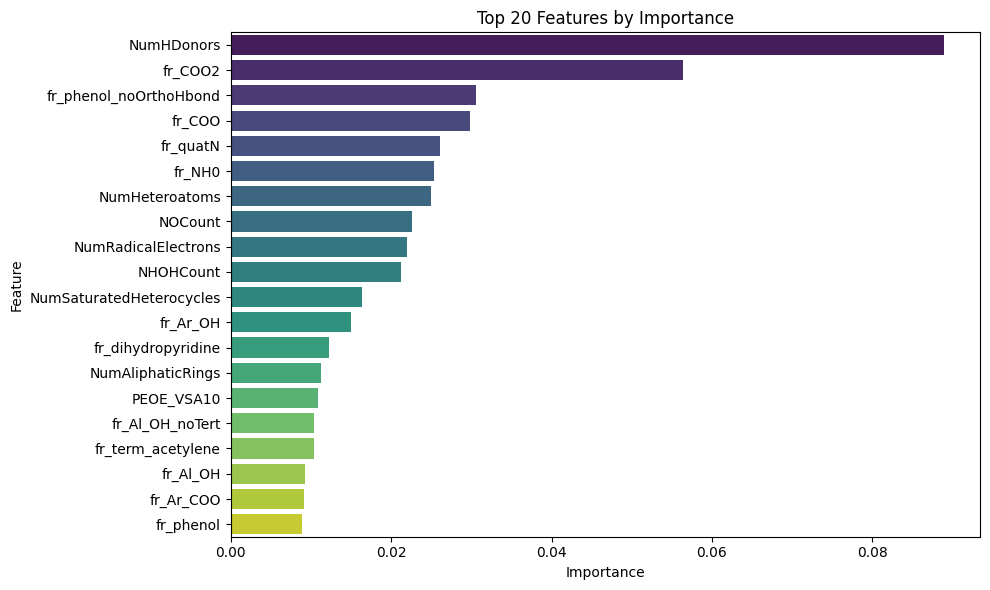

In [20]:
importances = model.feature_importances_

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': X_valid.columns,
    'Importance': importances
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot top 20 most important features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20), hue='Feature', palette='viridis', legend=False)
plt.title('Top 20 Features by Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Explanation:
- **Feature Importance**: This bar plot shows the relative importance of each feature in predicting BBB permeability. Features with higher importance values are more significant in determining whether a drug will cross the BBB.
- In drug discovery, understanding feature importance helps identify key molecular properties or chemical structures that influence BBB permeability.

### Conclusion

1. **Accuracy**: The model achieved a good accuracy of **0.8719**, meaning it correctly classified **87.19%** of the validation samples.

2. **Precision**: Precision of **0.8983** indicates that when the model predicts a positive outcome, it is correct **89.83%** of the time. This is important, especially in imbalanced datasets, where we aim to minimize false positives.

3. **Confusion Matrix**: The confusion matrix revealed that the model has a low number of false positives, which indicates that it is conservative when predicting positive outcomes.

4. **Precision-Recall Curve**: The precision-recall curve shows the trade-off between precision and recall. As expected, we see the precision decline slightly as recall increases. This indicates a balance between correctly identifying positives and not labeling negatives as positives.

5. **ROC Curve**: The ROC curve, with an AUC of **0.86**, demonstrates the model's ability to discriminate between the two classes effectively.

6. **Feature Importance**: The most important features were found to be **Number of Hydrogen Bond Donors - NUMHDonors**, **Fraction of Carboxyl Groups**, and **Fraction of Phenol Groups without Ortho Hydrogen Bonding - fr_Phenol_noOrthoHBand**, which aligned with domain knowledge and suggested factors influencing the outcome.

7. If NUMHDonors, fr_COO2, and fr_Phenol_noOrthoHBand emerge as the top features in our model, it suggests that **hydrogen bonding potential, polarity, and specific functional groups** play a dominant role in predicting blood-brain barrier permeability, potentially outweighing traditional factors like lipophilicity and molecular weight in this dataset.